===== MODEL PERFORMANCE =====
Mean Squared Error: 8.227460519607844
R2 Score: 0.8878080447367498


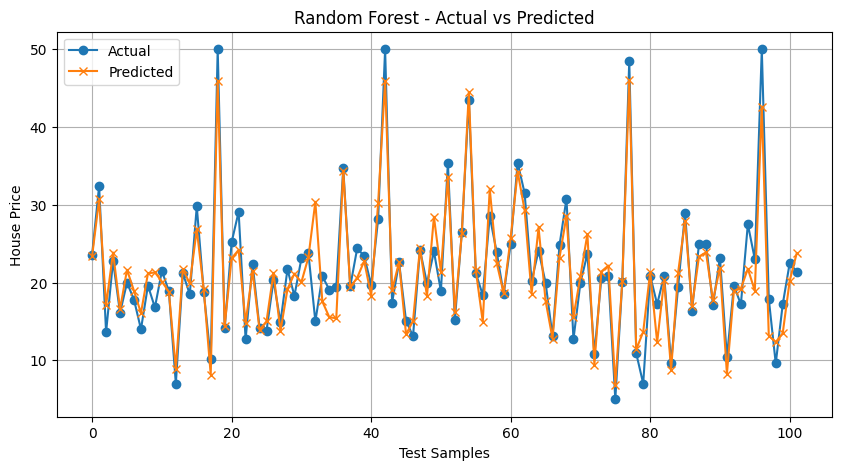

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('HousingData.csv')

target_column = 'MEDV'

X = df.drop(columns=[target_column])
y = df[target_column]

X = X.fillna(X.mean())
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("===== MODEL PERFORMANCE =====")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')

plt.title("Random Forest - Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.show()